In [1]:
import joblib
import numpy as np
import pandas as pd

# =========================================================
# HELPER
# =========================================================
def show_top_features(model, feature_names, top_n=20, model_name="model"):
    coefs = model.coef_.ravel()

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coef": coefs
    })

    top_ai = coef_df.sort_values("coef", ascending=False).head(top_n)
    top_human = coef_df.sort_values("coef", ascending=True).head(top_n)

    print(f"\n=== {model_name} : TOP {top_n} AI FEATURES ===")
    print(top_ai.round(4).to_string(index=False))

    print(f"\n=== {model_name} : TOP {top_n} HUMAN FEATURES ===")
    print(top_human.round(4).to_string(index=False))

    return coef_df.sort_values("coef", ascending=False)


In [ ]:


# =========================================================
# 1. TF-IDF MODEL
# =========================================================
tfidf_pipeline = joblib.load("outputs/saved_models/kaggle_tfidf_logreg_pipeline.pkl")

tfidf_vectorizer = tfidf_pipeline.named_steps["tfidf"]
tfidf_model = tfidf_pipeline.named_steps["logreg"]   

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

coef_tfidf = show_top_features(
    tfidf_model,
    tfidf_feature_names,
    top_n=20,
    model_name="TF-IDF"
)


# =========================================================
# 2. STYLOMETRIC MODEL
# =========================================================
stylo_model = joblib.load("outputs/saved_models/kaggle_stylometric_logreg.pkl")
stylo_feature_names = joblib.load("outputs/saved_models/kaggle_stylometric_feature_names.pkl")

coef_stylo = show_top_features(
    stylo_model,
    stylo_feature_names,
    top_n=20,
    model_name="Stylometric"
)


=== TF-IDF : TOP 20 AI FEATURES ===
      feature   coef
    important 3.0566
    potential 2.6246
    education 2.6012
 additionally 2.3526
        often 2.3326
      provide 2.0881
         such 2.0172
 young people 1.9631
      however 1.9394
        risks 1.9312
 important to 1.8991
understanding 1.8984
   successful 1.8751
           re 1.8490
      such as 1.8207
         both 1.8070
 is important 1.7706
  communities 1.7464
      quality 1.7320
      lead to 1.7309

=== TF-IDF : TOP 20 HUMAN FEATURES ===
  feature    coef
  because -6.3002
    venus -5.1176
    would -4.8245
      you -4.7717
  driving -4.6986
   people -4.6428
      car -3.7366
     they -3.5844
      was -3.5015
     have -3.4580
electoral -3.4120
     your -3.0556
     cars -3.0466
      but -3.0108
   advice -2.8438
       do -2.7531
      get -2.7334
   planet -2.6805
     will -2.6535
     nasa -2.5722

=== Stylometric : TOP 20 AI FEATURES ===
             feature   coef
     std_word_length 3.7566
      

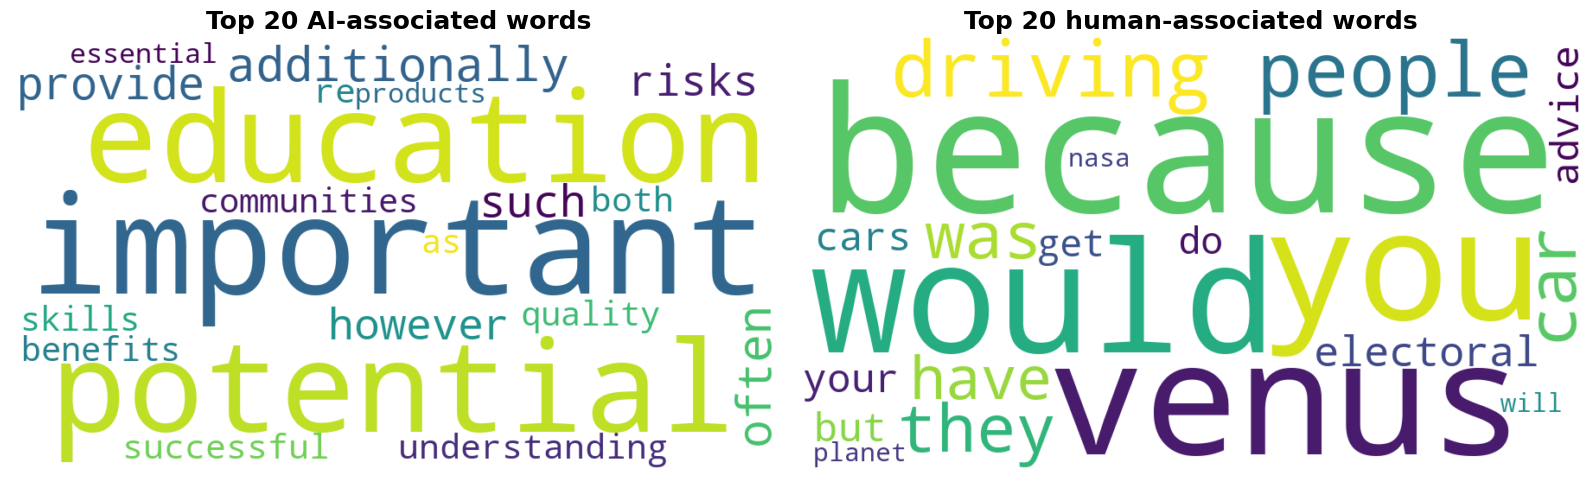

In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# =========================================================
# 1. LOAD SAVED TF-IDF PIPELINE
# =========================================================
tfidf_pipeline = joblib.load("outputs/saved_models/kaggle_tfidf_logreg_pipeline.pkl")

tfidf_vectorizer = tfidf_pipeline.named_steps["tfidf"]
tfidf_model = tfidf_pipeline.named_steps["logreg"]

feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
coefs = tfidf_model.coef_.ravel()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
})

# =========================================================
# 2. KEEP ONLY UNIGRAMS 
# =========================================================
coef_df = coef_df[~coef_df["feature"].str.contains(" ")].copy()

# =========================================================
# 3. TOP 20 AI WORDS AND TOP 20 HUMAN WORDS
# =========================================================
top_ai = coef_df.sort_values("coef", ascending=False).head(20)
top_human = coef_df.sort_values("coef", ascending=True).head(20)

# for the cloud, frequencies determine word sizes
ai_freq = dict(zip(top_ai["feature"], top_ai["abs_coef"]))
human_freq = dict(zip(top_human["feature"], top_human["abs_coef"]))

# =========================================================
# 4. WORD CLOUDS
# =========================================================
wc_ai = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate_from_frequencies(ai_freq)

wc_human = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate_from_frequencies(human_freq)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.imshow(wc_ai, interpolation="bilinear")
plt.axis("off")
plt.title("Top 20 AI-associated words", fontsize = 18, fontweight = "bold")

plt.subplot(1, 2, 2)
plt.imshow(wc_human, interpolation="bilinear")
plt.axis("off")
plt.title("Top 20 human-associated words", fontsize = 18, fontweight = "bold")

plt.tight_layout()
plt.savefig("Charts/wordclouds_side_by_side.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
import joblib
import pandas as pd

stylometric_model = joblib.load("outputs/saved_models/kaggle_stylometric_logreg.pkl")
stylo_feature_names = joblib.load("outputs/saved_models/kaggle_stylometric_feature_names.pkl")

coef_df = pd.DataFrame({
    "feature": stylo_feature_names,
    "coef": stylometric_model.coef_.ravel()
})

top_ai = coef_df.sort_values("coef", ascending=False).head(4)
top_human = coef_df.sort_values("coef", ascending=True).head(3)

print("Top 3 AI features:")
print(top_ai.to_string(index=False))

print("\nTop 3 human features:")
print(top_human.to_string(index=False))

Top 3 AI features:
        feature     coef
std_word_length 3.756591
      n_em_dash 1.983352
        count_— 1.983352
repetition_rate 1.396487

Top 3 human features:
          feature      coef
  pos_share_propn -1.395925
       n_ellipsis -1.329581
lexical_diversity -1.178453


In [7]:
import re
import numpy as np
import pandas as pd
from collections import Counter

# Load training corpus
kaggle_train = pd.read_csv("clean_data/Kaggle/kaggle_train.csv")

# Create readable class label
kaggle_train["text_origin"] = kaggle_train["generated"].map({
    0: "Human",
    1: "AI"
})


def compute_descriptive_stylometric_features(text):
    if pd.isna(text):
        text = ""
    text = str(text)

    words = re.findall(r"\b\w+\b", text)
    words_lower = [w.lower() for w in words]
    n_words = len(words)

    sentence_candidates = re.split(r"[.!?]+", text)
    sentences = [s.strip() for s in sentence_candidates if s.strip()]
    sentence_word_counts = [
        len(re.findall(r"\b\w+\b", sentence))
        for sentence in sentences
    ]

    word_lengths = [len(word) for word in words]

    lexical_diversity = (
        len(set(words_lower)) / n_words
        if n_words > 0 else np.nan
    )

    word_counts = Counter(words_lower)
    repeated_word_tokens = sum(
        count for count in word_counts.values()
        if count > 1
    )
    repetition_rate = (
        repeated_word_tokens / n_words
        if n_words > 0 else np.nan
    )

    return pd.Series({
        "average_sentence_length": np.mean(sentence_word_counts) if sentence_word_counts else np.nan,
        "lexical_diversity": lexical_diversity,
        "repetition_rate": repetition_rate,
        "word_length_std": np.std(word_lengths) if word_lengths else np.nan
    })


# Compute features
kaggle_train_stylometric_features = kaggle_train["text"].apply(
    compute_descriptive_stylometric_features
)

# Combine labels and features
kaggle_train_descriptive_stylometry = pd.concat(
    [
        kaggle_train[["text_origin", "generated"]],
        kaggle_train_stylometric_features
    ],
    axis=1
)

# Mean by Human / AI
kaggle_train_stylometry_summary = (
    kaggle_train_descriptive_stylometry
    .groupby("text_origin")
    [["average_sentence_length", "lexical_diversity", "repetition_rate", "word_length_std"]]
    .mean()
    .round(3)
)

kaggle_train_stylometry_summary

,average_sentence_length,lexical_diversity,repetition_rate,word_length_std
text_origin,,,,
AI,22.832,0.559,0.605,2.726
Human,22.325,0.443,0.724,2.257


<positron-console-cell-12>:9: SyntaxWarning: "\K" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\K"? A raw string is also an option.


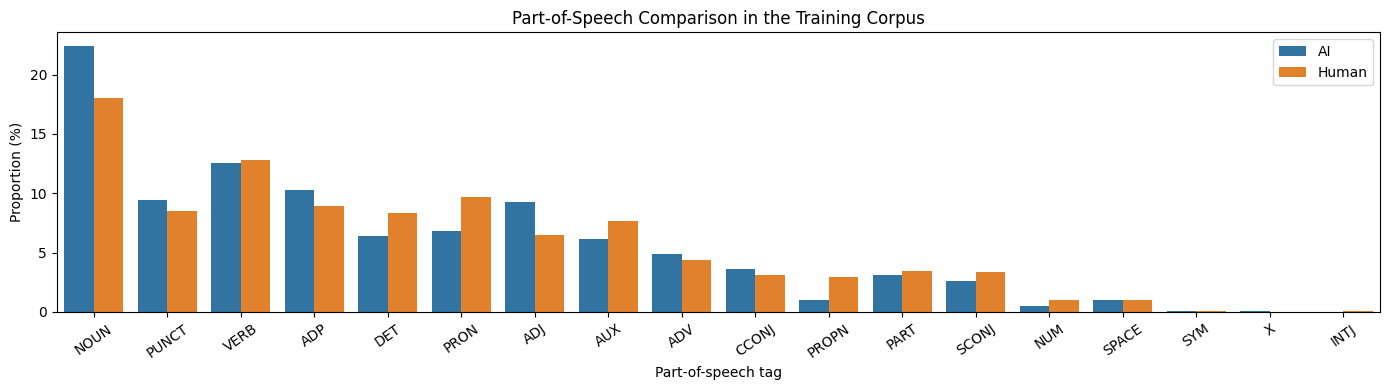

In [ ]:
import pandas as pd
import numpy as np
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load data
kaggle_train = pd.read_csv("clean_data\Kaggle\kaggle_train.csv")

kaggle_train["text_origin"] = kaggle_train["generated"].map({
    0: "Human",
    1: "AI"
})

# Load spaCy
nlp = spacy.load("en_core_web_sm", disable=["ner"])

pos_tags_to_keep = [
    "NOUN", "PUNCT", "VERB", "ADP", "DET", "PRON",
    "ADJ", "AUX", "ADV", "CCONJ", "PROPN", "PART",
    "SCONJ", "NUM", "SPACE", "SYM", "X", "INTJ"
]


def compute_pos_shares(text):
    if pd.isna(text):
        text = ""
    text = str(text)

    doc = nlp(text)

    pos_counts = Counter(token.pos_ for token in doc)
    n_tokens = sum(pos_counts.values())

    return pd.Series({
        pos_tag: pos_counts[pos_tag] / n_tokens if n_tokens > 0 else 0
        for pos_tag in pos_tags_to_keep
    })


# Compute POS shares for each text
kaggle_train_pos_shares = kaggle_train["text"].apply(compute_pos_shares)

# Add label
kaggle_train_pos_shares["text_origin"] = kaggle_train["text_origin"]

# Average POS shares by Human / AI
kaggle_train_pos_summary = (
    kaggle_train_pos_shares
    .groupby("text_origin")[pos_tags_to_keep]
    .mean()
    .reset_index()
)

# Long format for plotting
kaggle_train_pos_summary_long = kaggle_train_pos_summary.melt(
    id_vars="text_origin",
    var_name="pos_tag",
    value_name="share"
)

# Convert to percentages
kaggle_train_pos_summary_long["share_percent"] = (
    100 * kaggle_train_pos_summary_long["share"]
)

